#Gabrielle Johnson's Week 7 Final Deliverable


##Importing Libraries 📚

In [1]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: loads the Python "tools" (libraries) we need.
#   - pandas: works with tables of data (like a spreadsheet in code)
#   - matplotlib: draws charts
#   - scikit-learn (sklearn): the machine-learning toolkit
#   - joblib: saves a trained model to a file so we can reuse it later
# You only run this once at the top of the notebook.
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
#os.makedirs("figs", exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from pathlib import Path
from google.colab import drive

pd.set_option("display.width", 120)
print("Libraries loaded. ✅")

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score,
)

Libraries loaded. ✅


## Setting up the Environment ⚙

In [2]:
# mount Drive
drive.mount("/content/drive")
DATA_PATH = Path("/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Place the CSV beside this notebook, or set DATA_PATH (Colab).")

# index_col=0 drops the unnamed export row-number column
df = pd.read_csv(DATA_PATH, index_col=0)
print(f"Loaded {df.shape[0]:,} ED encounters  x  {df.shape[1]} columns")

#inspecting the data
#df.head()

Mounted at /content/drive
Loaded 55,121 ED encounters  x  225 columns


## Categorise Columns 🔗

In [3]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

chief_complaints = [col for col in df.columns if col.startswith("cc_")]

In [4]:
# Reference ranges for general adult triage since there are no paediatric patients. Each entry is (low, high, unit).
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

##Cleaning the Dataset 🧼

In [5]:
def clean_triage(raw):
    """
    Takes the raw DataFrame and returns a cleaned copy.
    """
    d = raw.copy()

    # Drop rows with no esi
    d = d[d[TARGET].notna()].copy()

    # Convert expected numeric fields to numeric
    numeric_cols = [c for c in VITALS if c in d.columns]
    if "age" in d.columns:
        numeric_cols.append("age")
    numeric_cols.append(TARGET)

    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # Drop rows where ESI became invalid after numeric conversion
    d = d[d[TARGET].notna()].copy()

    # Add impossible value flags only if implausible values exist
    for col, (low, high) in PLAUSIBLE.items():
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            if out_of_range.any():
                d[f"{col}_was_impossible"] = out_of_range.astype(int)

    # Add missingness flags only for vitals that have missing values
    for col in VITALS:
        if col in d.columns and d[col].isna().sum() > 0:
            d[f"{col}_was_missing"] = d[col].isna().astype(int)
            d[col] = d[col].fillna(d[col].median())

    # Oxygen device flag: blank means no device recorded
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = (
            pd.to_numeric(d["triage_vital_o2_device"], errors="coerce").fillna(0)
        )

    # Clean chief complaint flags
    for col in chief_complaints:
        d[col] = pd.to_numeric(d[col], errors="coerce").fillna(0)
        d[col] = (d[col] == 1).astype(int)

    # Clean categorical text columns
    for col in DEMOGRAPHICS + ADMIN + LEAKAGE:
        if col in d.columns and d[col].dtype == object:
            d[col] = (
                d[col].astype(str).str.strip()
                .replace({"": "Unknown", "nan": "Unknown", "NaN": "Unknown",
                          "None": "Unknown", "NONE": "Unknown"})
                .fillna("Unknown")
            )

    # Convert target to integer
    d[TARGET] = d[TARGET].round().astype(int)

    return d

In [6]:
df=clean_triage(df)
#df.head()

##Choosing the Features (X) and the Target (y)

In [7]:
X = df[FEATURES]     #the clues the model may use to make that prediction
y = df[TARGET]       #the thing we want to PREDICT  -> esi (the triage level 1-5)

print("Model will use", len(FEATURES), "features to predict:", TARGET)
print("First few features:", FEATURES[:10], "...")

Model will use 208 features to predict: esi
First few features: ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp', 'triage_glucose', 'cc_abdominalcramping', 'cc_abdominaldistention'] ...


##Split into training and test sets 🏋
> Uses random_state= 42

In [8]:
#separates a TEST set (20%) that the model will not see during training, so later we can grade it honestly.
#stratify=y keeps the ESI mix balanced across both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

Training patients: 44096
Testing patients:  11025


## A baseline to beat (DummyClassifier) 🥊

In [9]:
#prediction based only on the class distribution, not on the features
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
print(f"Dummy baseline accuracy: {dummy.score(X_test, y_test):.2f}")

Dummy baseline accuracy: 0.38


In [10]:
pred_dummy = dummy.predict(X_test)
print(f"Dummy baseline accuracy: {dummy.score(X_test, y_test):.2f}")

Dummy baseline accuracy: 0.38


##Logistic Regression 🧠♻






In [11]:
# scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# train the model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
print(f"Scaled logistic regression test accuracy: {logreg.score(X_test_scaled, y_test):.3f}")



Scaled logistic regression test accuracy: 0.667


## Predictions on the Test Set

In [12]:
#get the predicted ESI for the test set.
pred_logreg =logreg.predict(X_test_scaled)
print("Example predictions (logreg):", pred_logreg[:10])

Example predictions (logreg): [2 3 3 2 2 2 3 3 3 2]


## Confusion Matrix 🔍

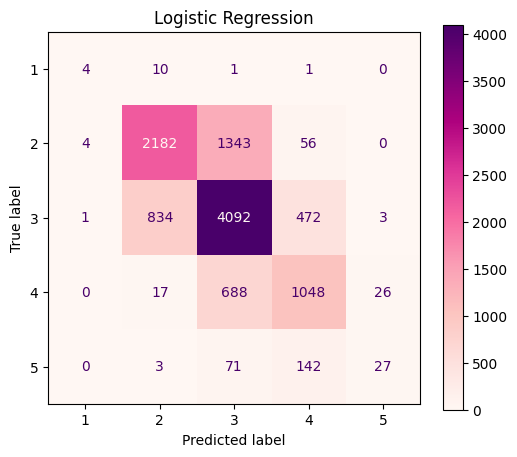

In [13]:
#confusion matrix
# Rows = true ESI, columns = predicted ESI. Diagonal = correct.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, cmap="RdPu")
ax.set_title("Logistic Regression")
fig.savefig("/content/drive/MyDrive/confusion_matrix_logreg.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Accuracy, Precision, Recall, F1, Classification Report 📊📝




In [14]:
#weighted f1 score- weighted by class size,Skews toward the majority class.
f1_weighted=f1_score(y_test, pred_logreg, average='weighted')
print(f"F1_Score Weighted: {f1_weighted:.3f}")

#macro f1 score - every esi level counts equally
f1_macro=f1_score(y_test, pred_logreg, average='macro')
print(f"\nF1_ Score Macro: {f1_macro:.3f}")

#specifically looking at the recall for esi 1
recall=recall_score(y_test, pred_logreg, labels=[1], average=None)[0]
print(f"\nRecall for ESI 1: {recall:.3f}")

#Classification report
print(f"\nClassification report:\n{classification_report(y_test, pred_logreg)}")

F1_Score Weighted: 0.661

F1_ Score Macro: 0.493

Recall for ESI 1: 0.250

Classification report:
              precision    recall  f1-score   support

           1       0.44      0.25      0.32        16
           2       0.72      0.61      0.66      3585
           3       0.66      0.76      0.71      5402
           4       0.61      0.59      0.60      1779
           5       0.48      0.11      0.18       243

    accuracy                           0.67     11025
   macro avg       0.58      0.46      0.49     11025
weighted avg       0.67      0.67      0.66     11025



##Decision Tree 🌳

In [15]:
#train model
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)
print("Example predictions (tree):", pred_tree[:10])

print(f"Train accuracy: {tree.score(X_train, y_train):.3f}")
print(f"Test accuracy:  {tree.score(X_test, y_test):.3f}")

Example predictions (tree): [2 3 2 2 2 2 2 3 2 2]
Train accuracy: 1.000
Test accuracy:  0.558


In [16]:
#limit depth for overfitting
tree = DecisionTreeClassifier(max_depth=30, min_samples_leaf=20, random_state=42)#max_depth=30 was chosen because test accuracy plateaus around there
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

print(f"Train accuracy: {tree.score(X_train, y_train):.3f}")
print(f"Test accuracy:  {tree.score(X_test, y_test):.3f}")

Train accuracy: 0.653
Test accuracy:  0.614


## Accuracy, Precision, Recall, F1, Classification Report 📊📝

F1_Score Weighted: 0.588
F1_Score Macro: 0.349
Recall for ESI 1: 0.000

Classification report:
              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.710     0.506     0.591      3585
           3      0.584     0.833     0.687      5402
           4      0.612     0.247     0.352      1779
           5      0.378     0.070     0.118       243

    accuracy                          0.614     11025
   macro avg      0.457     0.331     0.349     11025
weighted avg      0.624     0.614     0.588     11025



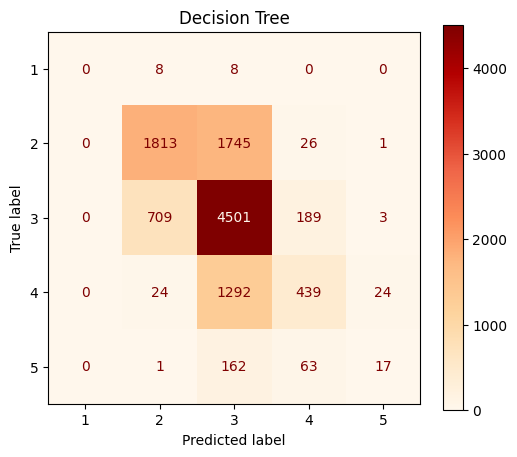

In [17]:
#f1_weighted,weighted by class size,Skews toward the majority class.
f1_weighted_tree = f1_score(y_test, pred_tree, average='weighted')
print(f"F1_Score Weighted: {f1_weighted_tree:.3f}")

#f1_macro,every esi level counts equally
f1_macro_tree = f1_score(y_test, pred_tree, average='macro')
print(f"F1_Score Macro: {f1_macro_tree:.3f}")

#recall for esi1
recall_tree = recall_score(y_test, pred_tree, labels=[1], average=None, zero_division=0)[0]
print(f"Recall for ESI 1: {recall_tree:.3f}")

#classification report
print(f"\nClassification report:\n{classification_report(y_test, pred_tree, digits=3, zero_division=0)}")

#confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_tree,ax=ax, cmap="OrRd")
ax.set_title("Decision Tree")
fig.savefig("/content/drive/MyDrive/confusion_matrix_tree.png", dpi=150, bbox_inches="tight")
plt.show()

##Exploring Balanced Models ⚖🌳

In [18]:
#a balanced decision tree to take account of the <1% esi 1
tree_bal = DecisionTreeClassifier(min_samples_leaf=20, class_weight="balanced", random_state=42)
tree_bal.fit(X_train, y_train)
pred_tree_bal = tree_bal.predict(X_test)

print(f"Train accuracy: {tree_bal.score(X_train, y_train):.3f}")
print(f"Test accuracy:  {tree_bal.score(X_test, y_test):.3f}")
print(f"\nF1 Weighted: {f1_score(y_test, pred_tree_bal, average='weighted'):.3f}")
print(f"F1 Macro: {f1_score(y_test, pred_tree_bal, average='macro'):.3f}")
print(f"Recall for ESI 1: {recall_score(y_test, pred_tree_bal, labels=[1], average=None, zero_division=0)[0]:.3f}")
print(f"\n{classification_report(y_test, pred_tree_bal, digits=3, zero_division=0)}")

Train accuracy: 0.590
Test accuracy:  0.516

F1 Weighted: 0.539
F1 Macro: 0.378
Recall for ESI 1: 0.500

              precision    recall  f1-score   support

           1      0.054     0.500     0.097        16
           2      0.617     0.604     0.610      3585
           3      0.699     0.433     0.535      5402
           4      0.380     0.582     0.460      1779
           5      0.110     0.588     0.186       243

    accuracy                          0.516     11025
   macro avg      0.372     0.541     0.378     11025
weighted avg      0.607     0.516     0.539     11025



In [19]:
# balanced logistic regression
logreg_bal = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
logreg_bal.fit(X_train_scaled, y_train)
pred_logreg_bal = logreg_bal.predict(X_test_scaled)

print(f"Test accuracy: {logreg_bal.score(X_test_scaled, y_test):.3f}")
print(f"F1 Weighted: {f1_score(y_test, pred_logreg_bal, average='weighted'):.3f}")
print(f"F1 Macro: {f1_score(y_test, pred_logreg_bal, average='macro'):.3f}")
print(f"Recall for ESI 1: {recall_score(y_test, pred_logreg_bal, labels=[1], average=None)[0]:.3f}")
print(f"\nClassification report:\n{classification_report(y_test, pred_logreg_bal, digits=3, zero_division=0)}")

Test accuracy: 0.563
F1 Weighted: 0.596
F1 Macro: 0.411
Recall for ESI 1: 0.625

Classification report:
              precision    recall  f1-score   support

           1      0.017     0.625     0.032        16
           2      0.658     0.602     0.629      3585
           3      0.762     0.500     0.604      5402
           4      0.488     0.655     0.559      1779
           5      0.139     0.691     0.231       243

    accuracy                          0.563     11025
   macro avg      0.413     0.615     0.411     11025
weighted avg      0.669     0.563     0.596     11025



##Summary 📝

In [20]:
#comparison of all models vs the dummy baseline
results = {}
for name, pred in [("Dummy", pred_dummy),
                   ("Logistic Regression", pred_logreg),
                   ("Decision Tree", pred_tree),
                   ("Logistic Regression (balanced)", pred_logreg_bal),
                   ("Decision Tree (balanced)", pred_tree_bal)]:
    r1, r2, r3, r4, r5 = recall_score(y_test, pred, labels=[1, 2, 3, 4, 5], average=None, zero_division=0)
    p1, p2, p3, p4, p5 = precision_score(y_test, pred, labels=[1, 2, 3, 4, 5], average=None, zero_division=0)
    results[name] = {
        "ESI1 Recall": r1, "ESI1 Precision": p1,
        "ESI2 Recall": r2, "ESI2 Precision": p2,
        "ESI3 Recall": r3, "ESI3 Precision": p3,
        "ESI4 Recall": r4, "ESI4 Precision": p4,
        "ESI5 Recall": r5, "ESI5 Precision": p5,
        "Accuracy": (pred == y_test).mean(),
        "F1 Weighted": f1_score(y_test, pred, average="weighted"),
        "F1 Macro": f1_score(y_test, pred, average="macro"),
    }

comparison = pd.DataFrame(results).T.round(3)
print(comparison)

                                ESI1 Recall  ESI1 Precision  ESI2 Recall  ESI2 Precision  ESI3 Recall  ESI3 Precision  \
Dummy                                 0.000           0.000        0.327           0.334        0.498           0.491   
Logistic Regression                   0.250           0.444        0.609           0.716        0.757           0.661   
Decision Tree                         0.000           0.000        0.506           0.710        0.833           0.584   
Logistic Regression (balanced)        0.625           0.017        0.602           0.658        0.500           0.762   
Decision Tree (balanced)              0.500           0.054        0.604           0.617        0.433           0.699   

                                ESI4 Recall  ESI4 Precision  ESI5 Recall  ESI5 Precision  Accuracy  F1 Weighted  \
Dummy                                 0.148           0.147        0.045           0.049     0.375        0.375   
Logistic Regression                   0.589

##Saving Trained Model 🤖

In [21]:
save_model = Path("/content/drive/MyDrive/trained_models")
save_model.mkdir(exist_ok=True)

# scaler
joblib.dump(scaler, save_model / "scaler.joblib")

# unweighted models
joblib.dump(logreg, save_model / "model_logreg.joblib")
joblib.dump(tree,   save_model / "model_tree.joblib")

# class-weight balanced variants
joblib.dump(logreg_bal, save_model / "model_logreg_balanced.joblib")
joblib.dump(tree_bal,   save_model / "model_tree_balanced.joblib")

print("Saved to Drive!")

Saved to Drive!


#Week 7



> Additional Models and Features were evaluated 💻📊





###Adding Demographics to the Feature Set

In [22]:
# adding additional columns to the existing features
EXTRA = ["age", "gender", "arrivalmode"]
X_new = pd.get_dummies(df[FEATURES + EXTRA],
                       columns=["gender", "arrivalmode"],   # one hot encoding gender and arrivalmode
                       drop_first=True,
                       dtype=int)

print(f"Before: {len(FEATURES)} features  →  After: {X_new.shape[1]} features")
print([c for c in X_new.columns if c.startswith(("gender_", "arrivalmode_"))])

Before: 208 features  →  After: 216 features
['gender_Male', 'arrivalmode_Other', 'arrivalmode_Police', 'arrivalmode_Public Transportation', 'arrivalmode_Walk-in', 'arrivalmode_Wheelchair', 'arrivalmode_ambulance']


###Logistic Regression with Demographic Features


In [23]:
# Re-split training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, stratify=y, random_state=42)

# Refit the scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# re-train the logistic model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
print(f"Scaled logistic regression test accuracy: {logreg.score(X_test_scaled, y_test):.3f}")

Scaled logistic regression test accuracy: 0.686


In [24]:
#get the predicted ESI for the test set.
pred_logreg =logreg.predict(X_test_scaled)
print("Example predictions (logreg):", pred_logreg[:10])

Example predictions (logreg): [2 3 3 2 2 2 3 3 3 2]


In [25]:
#Classification report
print(f"\nClassification report:\n{classification_report(y_test,pred_logreg)}")


Classification report:
              precision    recall  f1-score   support

           1       0.50      0.25      0.33        16
           2       0.74      0.62      0.67      3585
           3       0.68      0.78      0.72      5402
           4       0.64      0.63      0.63      1779
           5       0.48      0.12      0.19       243

    accuracy                           0.69     11025
   macro avg       0.61      0.48      0.51     11025
weighted avg       0.69      0.69      0.68     11025



###Decision Tree with Demographic Features

In [26]:
#limit depth for overfitting
tree = DecisionTreeClassifier(max_depth=30, min_samples_leaf=20, random_state=42)#max_depth=30 was chosen because test accuracy plateaus around there
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

print(f"Train accuracy: {tree.score(X_train, y_train):.3f}")
print(f"Test accuracy:  {tree.score(X_test, y_test):.3f}")

#classification report
print(f"\nClassification report:\n{classification_report(y_test, pred_tree, digits=3, zero_division=0)}")

Train accuracy: 0.676
Test accuracy:  0.630

Classification report:
              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.695     0.540     0.608      3585
           3      0.617     0.778     0.688      5402
           4      0.569     0.438     0.495      1779
           5      0.522     0.099     0.166       243

    accuracy                          0.630     11025
   macro avg      0.480     0.371     0.391     11025
weighted avg      0.631     0.630     0.618     11025



###Feature Engineering 📠


> builds new clues from existing columns using clinical knowledge



In [27]:
def add_clinical_features(data):
    out = data.copy()

    # --- ratios & combinations ---
    out["shock_index"]    = out["triage_vital_hr"] / out["triage_vital_sbp"]       # HR / SBP
    out["pulse_pressure"] = out["triage_vital_sbp"] - out["triage_vital_dbp"]      # SBP - DBP
    out["spo2_rr_ratio"]  = out["triage_vital_o2"] / out["triage_vital_rr"]        # oxygen vs effort

    # --- red-flag indicators (no blood pressure) ---
    out["is_tachypneic"]     = (out["triage_vital_rr"]   > 20    ).astype(int)  # fast breathing
    out["is_hypoxic"]        = (out["triage_vital_o2"]   < 92    ).astype(int)  # low oxygen
    out["is_febrile"]        = (out["triage_vital_temp"] >= 100.4).astype(int)  # fever
    out["is_hypothermic"]    = (out["triage_vital_temp"] < 96.8  ).astype(int)  # low temp
    out["is_bradycardic"]    = (out["triage_vital_hr"]   < 60    ).astype(int)  # slow heart
    out["is_tachycardic"]    = (out["triage_vital_hr"]   > 100   ).astype(int)  # fast heart
    out["is_hyperglycaemic"] = (out["triage_glucose"]    > 180   ).astype(int)  # high glucose

    out["resp_distress"] = ((out["is_hypoxic"] == 1) | (out["is_tachypneic"] == 1)).astype(int)#respiratory distress

    # --- severity score: how many red flags fire ---
    flag_cols = ["is_tachypneic", "is_hypoxic", "is_febrile", "is_hypothermic",
                 "is_bradycardic", "is_tachycardic", "is_hyperglycaemic"]
    out["red_flag_count"] = out[flag_cols].sum(axis=1)

    # guard against divide-by-zero in the ratios (SBP or RR recorded as 0)
    out = out.replace([np.inf, -np.inf], np.nan).fillna(0)

    return out

X_train_fe = add_clinical_features(X_train)
X_test_fe  = add_clinical_features(X_test)
print("Features after engineering:", X_train_fe.shape[1])
#X_train_fe.head()


Features after engineering: 228


###Logistic Regression with features engineered 🚧

In [28]:
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)   # fit on train
X_test_fe_scaled  = scaler_fe.transform(X_test_fe)        # apply same scaling to test

logreg_fe = LogisticRegression(max_iter=1000, random_state=42)
logreg_fe.fit(X_train_fe_scaled, y_train)
pred_logreg_fe = logreg_fe.predict(X_test_fe_scaled)

print(f"Train accuracy: {logreg_fe.score(X_train_fe_scaled, y_train):.3f}")
print(f"Test accuracy:  {logreg_fe.score(X_test_fe_scaled, y_test):.3f}")
print(classification_report(y_test, pred_logreg_fe, digits=3, zero_division=0))


Train accuracy: 0.695
Test accuracy:  0.690
              precision    recall  f1-score   support

           1      0.455     0.312     0.370        16
           2      0.744     0.625     0.679      3585
           3      0.681     0.779     0.727      5402
           4      0.636     0.630     0.633      1779
           5      0.483     0.119     0.191       243

    accuracy                          0.690     11025
   macro avg      0.600     0.493     0.520     11025
weighted avg      0.690     0.690     0.684     11025



##Neural Networks 🧠

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline

mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(64, 32), #used (64,32) because it had less overfitting
                  alpha=1e-3,
                  max_iter=500,
                  early_stopping=True, #prevents overfitting
                  random_state=42))
mlp.fit(X_train_fe, y_train)
pred_mlp = mlp.predict(X_test_fe)

print(f"Train accuracy: {mlp.score(X_train_fe, y_train):.3f}")
print(f"Test accuracy:  {mlp.score(X_test_fe, y_test):.3f}")
print(classification_report(y_test, pred_mlp, digits=3, zero_division=0))

Train accuracy: 0.713
Test accuracy:  0.688
              precision    recall  f1-score   support

           1      0.600     0.188     0.286        16
           2      0.761     0.604     0.674      3585
           3      0.672     0.797     0.729      5402
           4      0.637     0.609     0.622      1779
           5      0.472     0.140     0.216       243

    accuracy                          0.688     11025
   macro avg      0.629     0.467     0.505     11025
weighted avg      0.691     0.688     0.682     11025



##Random Forest 🌳

In [30]:
rf = RandomForestClassifier(n_estimators=300,
                            class_weight="balanced",
                            random_state=42,
                            n_jobs=-1)
rf.fit(X_train_fe, y_train)
pred_rf = rf.predict(X_test_fe)

print(f"Train accuracy: {rf.score(X_train_fe, y_train):.3f}")
print(f"Test accuracy:  {rf.score(X_test_fe, y_test):.3f}")
print(classification_report(y_test, pred_rf, digits=3, zero_division=0))

# which features the forest leaned on
importances = pd.Series(rf.feature_importances_, index=X_train_fe.columns)
print(importances.sort_values(ascending=False).head(15))

Train accuracy: 1.000
Test accuracy:  0.649
              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.711     0.572     0.634      3585
           3      0.626     0.805     0.705      5402
           4      0.640     0.413     0.502      1779
           5      0.404     0.078     0.131       243

    accuracy                          0.649     11025
   macro avg      0.476     0.374     0.394     11025
weighted avg      0.650     0.649     0.635     11025

age                       0.070365
triage_vital_sbp          0.064956
shock_index               0.063646
triage_vital_dbp          0.060277
pulse_pressure            0.056746
triage_glucose            0.055804
triage_vital_hr           0.055059
triage_vital_temp         0.052820
spo2_rr_ratio             0.048004
triage_vital_o2           0.032783
arrivalmode_ambulance     0.032748
cc_strokealert            0.032048
triage_vital_rr           0.026578
cc_abdominal

In [31]:
#searches random forest settings with 3-fold CV and keeps the combination that scores best on macro-F1.
param_dist = {
    "n_estimators": [100, 200],
    "max_depth": [None, 6, 10, 16],
    "min_samples_leaf": [2, 4, 8],
    "max_features": ["sqrt", "log2"],
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=6,
    cv=3,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1,
    verbose=2)
search.fit(X_train_fe, y_train)

print("Best params:", search.best_params_)
print("Best CV macro-F1:", round(search.best_score_, 3))

best_rf = search.best_estimator_
pred_best_rf = best_rf.predict(X_test_fe)
print("Test macro-F1:", round(f1_score(y_test, pred_best_rf, average='macro'), 3))
print(f"Test accuracy: {best_rf.score(X_test_fe, y_test):.3f}")
print(classification_report(y_test, pred_best_rf, digits=3, zero_division=0))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'n_estimators': 100, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 16}
Best CV macro-F1: 0.41
Test macro-F1: 0.414
Test accuracy: 0.514
              precision    recall  f1-score   support

           1      0.238     0.312     0.270        16
           2      0.562     0.732     0.636      3585
           3      0.781     0.320     0.454      5402
           4      0.359     0.656     0.464      1779
           5      0.158     0.564     0.247       243

    accuracy                          0.514     11025
   macro avg      0.420     0.517     0.414     11025
weighted avg      0.627     0.514     0.510     11025



##Gradient Boost

In [32]:
hgb= HistGradientBoostingClassifier(
    max_depth=None, max_leaf_nodes=31,      # default tree shape
    learning_rate=0.1, max_iter=1000,
    early_stopping=True, validation_fraction=0.1,
    random_state=42)

hgb.fit(X_train_fe, y_train)
pred_hgb = hgb.predict(X_test_fe)
print(f"Train accuracy: {hgb.score(X_train_fe, y_train):.3f}")
print(f"Test accuracy: {hgb.score(X_test_fe, y_test):.3f}")
print(classification_report(y_test, pred_hgb, digits=3, zero_division=0))

Train accuracy: 0.747
Test accuracy: 0.692
              precision    recall  f1-score   support

           1      0.333     0.312     0.323        16
           2      0.741     0.652     0.693      3585
           3      0.687     0.774     0.728      5402
           4      0.639     0.602     0.620      1779
           5      0.415     0.160     0.231       243

    accuracy                          0.692     11025
   macro avg      0.563     0.500     0.519     11025
weighted avg      0.690     0.692     0.688     11025



###Focusing on ESI 2,3,4 recall and under-triaging 🔬


> Consistent with the Week 6 documentation and clinical guidance from Dr. De Freitas, evaluation focuses on per-class recall for ESI levels 2,3,4, with particular attention to minimising under-triaging — the most consequential error



In [33]:
def undertriage_report(y_true, y_pred, name):
  #looking at how many patients were undertriaged from ESI 2,3,4 in the varying models
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rows = {}
    for level in [2, 3, 4]:
        mask = y_true == level
        rows[f"ESI {level}"] = {
            "under-triaged %": round(100 * (y_pred[mask] > level).mean(), 1)}
            #,"sent to ESI 5 %": round(100 * (y_pred[mask] == 5).mean(), 1)}
    print(f"\n{name}")
    print(pd.DataFrame(rows).T)

for name, pred in [("LogReg", pred_logreg_fe), ("MLP", pred_mlp),
                   ("HGB", pred_hgb)]:
    undertriage_report(y_test, pred, name)


LogReg
       under-triaged %
ESI 2             37.4
ESI 3              8.3
ESI 4              1.5

MLP
       under-triaged %
ESI 2             39.5
ESI 3              8.2
ESI 4              1.8

HGB
       under-triaged %
ESI 2             34.6
ESI 3              8.0
ESI 4              2.6


##Class Weightings 🏋

In [51]:
#exploring weighting options and how they affect performance specifically recall and precision
weight_options = [
    {1:1, 2:1.5, 3:1, 4:1, 5:1},
    {1:1, 2:2,   3:1, 4:1, 5:1},
    {1:1, 2:3,   3:1, 4:1, 5:1},
    {1:1, 2:2.5,   3:1, 4:1.5, 5:1},
    {1:1, 2:2, 3:1, 4:1.2, 5:1}
]

for w in weight_options:
    sw = y_train.map(w).values
    m = HistGradientBoostingClassifier(
        max_depth=None, max_leaf_nodes=31, learning_rate=0.1, max_iter=1000,
        early_stopping=True, validation_fraction=0.1, random_state=42)
    m.fit(X_train_fe, y_train, sample_weight=sw)
    p = m.predict(X_test_fe)
    yt = np.asarray(y_test)
    under = {lvl: 100 * (p[yt == lvl] > lvl).mean() for lvl in [2, 3, 4]}
    r2, r3, r4 = recall_score(y_test, p, labels=[2,3,4], average=None)
    p2, p3, p4 = precision_score(y_test, p, labels=[2,3,4], average=None, zero_division=0)
    print(f"w={w}  acc={(p==y_test).mean():.3f}  "
          f"under-triage 2/3/4: {under[2]:.1f}%/{under[3]:.1f}%/{under[4]:.1f}%  "
          f"R: {r2:.3f}/{r3:.3f}/{r4:.3f}  P: {p2:.3f}/{p3:.3f}/{p4:.3f}")

w={1: 1, 2: 1.5, 3: 1, 4: 1, 5: 1}  acc=0.671  under-triage 2/3/4: 26.5%/6.2%/3.0%  R: 0.723/0.709/0.526  P: 0.667/0.690/0.663
w={1: 1, 2: 2, 3: 1, 4: 1, 5: 1}  acc=0.636  under-triage 2/3/4: 19.6%/4.9%/2.9%  R: 0.797/0.620/0.430  P: 0.593/0.682/0.679
w={1: 1, 2: 3, 3: 1, 4: 1, 5: 1}  acc=0.643  under-triage 2/3/4: 14.6%/7.9%/3.2%  R: 0.853/0.543/0.595  P: 0.579/0.735/0.647
w={1: 1, 2: 2.5, 3: 1, 4: 1.5, 5: 1}  acc=0.654  under-triage 2/3/4: 16.8%/11.9%/1.7%  R: 0.831/0.544/0.711  P: 0.603/0.759/0.593
w={1: 1, 2: 2, 3: 1, 4: 1.2, 5: 1}  acc=0.653  under-triage 2/3/4: 19.9%/8.8%/2.4%  R: 0.791/0.603/0.604  P: 0.612/0.724/0.613


###Gradient Boosting with Class Weightings 📈 🏋

              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.593     0.797     0.680      3585
           3      0.682     0.620     0.649      5402
           4      0.679     0.430     0.526      1779
           5      0.374     0.152     0.216       243

    accuracy                          0.636     11025
   macro avg      0.465     0.400     0.415     11025
weighted avg      0.645     0.636     0.629     11025


HGB weighted
       under-triaged %
ESI 2             19.6
ESI 3              4.9
ESI 4              2.9


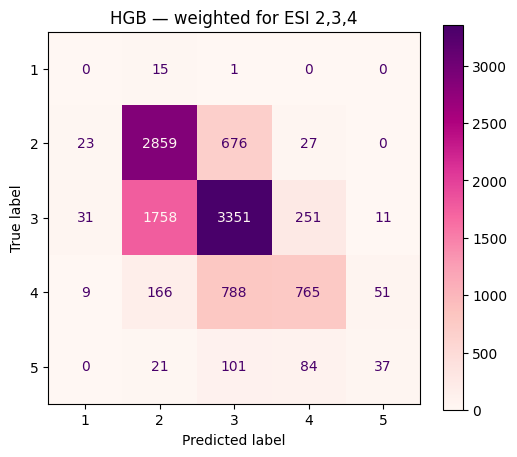

['/content/drive/MyDrive/trained_models/model_hgb_weighted.joblib']

In [35]:
w_final = {1:1, 2:2, 3:1, 4:1, 5:1} # the class weighting that gave the best results of preventing under-triaging whilst still maintaining recall
sw = y_train.map(w_final).values
hgb_final = HistGradientBoostingClassifier(
    max_depth=None, max_leaf_nodes=31, learning_rate=0.1, max_iter=1000,
    early_stopping=True, validation_fraction=0.1, random_state=42)
hgb_final.fit(X_train_fe, y_train, sample_weight=sw)
pred_final = hgb_final.predict(X_test_fe)

print(classification_report(y_test, pred_final, digits=3, zero_division=0))
undertriage_report(y_test, pred_final, "HGB weighted")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_final, ax=ax, cmap="RdPu")
ax.set_title("HGB — weighted for ESI 2,3,4")
fig.savefig("/content/drive/MyDrive/confusion_matrix_hgb_final.png", dpi=150, bbox_inches="tight")
plt.show()

joblib.dump(hgb_final, save_model / "model_hgb_weighted.joblib")

###Logistic Regression with Class Weightings 🏋

              precision    recall  f1-score   support

           1      0.667     0.125     0.211        16
           2      0.631     0.785     0.699      3585
           3      0.717     0.630     0.671      5402
           4      0.638     0.630     0.634      1779
           5      0.492     0.119     0.192       243

    accuracy                          0.668     11025
   macro avg      0.629     0.458     0.481     11025
weighted avg      0.671     0.668     0.663     11025


LogReg weighted
       under-triaged %
ESI 2             21.5
ESI 3              8.2
ESI 4              1.5


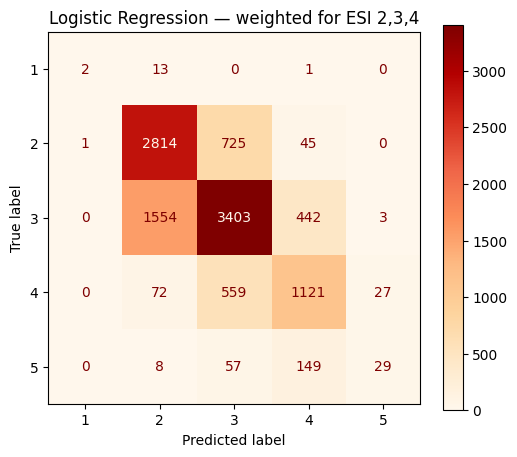

In [36]:
logreg_w = LogisticRegression(max_iter=1000, class_weight={1:1, 2:2, 3:1, 4:1, 5:1},
                              random_state=42)
logreg_w.fit(X_train_fe_scaled, y_train)
pred_logreg_w = logreg_w.predict(X_test_fe_scaled)
print(classification_report(y_test, pred_logreg_w, digits=3, zero_division=0))
undertriage_report(y_test, pred_logreg_w, "LogReg weighted")
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg_w, ax=ax, cmap="OrRd")
ax.set_title("Logistic Regression — weighted for ESI 2,3,4")
fig.savefig("/content/drive/MyDrive/confusion_matrix_lrw_final.png", dpi=150, bbox_inches="tight")
plt.show()

##Ensemble Models 🎰


> averaging them (voting) or learning how to
weight them (stacking) usually beats any one model alone



In [37]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

# Same weighting
W = {1: 1, 2: 2, 3: 1, 4: 1, 5: 1}
#shift the keys by -1 for base learners
W_enc = {esi - 1: w for esi, w in W.items()}   # {0:1, 1:2, 2:1, 3:1, 4:1}

# Logistic Regression
base_logreg = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight=W_enc, random_state=42)),
])

#Neural network (MLP)
base_mlp = Pipeline([
    ("scale", StandardScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1e-3, max_iter=500,
                          early_stopping=True, random_state=42)),
])

# Histogram Gradient Boosting (trees)

base_hgb = HistGradientBoostingClassifier(
    max_leaf_nodes=31, learning_rate=0.1, max_iter=1000,
    early_stopping=True, validation_fraction=0.1,
    class_weight=W_enc, random_state=42)

print("Base learners ready: LogReg (linear), MLP (neural net), HGB (trees)")

Base learners ready: LogReg (linear), MLP (neural net), HGB (trees)


###Soft Voting ☑


> soft voting averages the esi probabilities that each model outputs and picks the highest.



In [38]:
voting = VotingClassifier(
    estimators=[("logreg", base_logreg), ("mlp", base_mlp), ("hgb", base_hgb)],
    voting="soft",        # average predicted probabilities
    weights=[2, 1, 2],    # weigh on hgb the most, as it was the most accurate of the 3
    n_jobs=-1)

voting.fit(X_train_fe, y_train)
pred_voting = voting.predict(X_test_fe)

print(f"Train accuracy: {voting.score(X_train_fe, y_train):.3f}")
print(f"Test accuracy:  {voting.score(X_test_fe, y_test):.3f}")
print(classification_report(y_test, pred_voting, digits=3, zero_division=0))
undertriage_report(y_test, pred_voting, "Voting ensemble")

Train accuracy: 0.693
Test accuracy:  0.679
              precision    recall  f1-score   support

           1      0.167     0.062     0.091        16
           2      0.657     0.767     0.708      3585
           3      0.708     0.678     0.693      5402
           4      0.654     0.588     0.619      1779
           5      0.431     0.115     0.182       243

    accuracy                          0.679     11025
   macro avg      0.523     0.442     0.458     11025
weighted avg      0.676     0.679     0.674     11025


Voting ensemble
       under-triaged %
ESI 2             23.2
ESI 3              6.9
ESI 4              1.9


###Stacking 📚


> Stacking trains a meta-model on the base models' cross validated probabilities, so it learns how much
to trust each base model per ESI level



In [39]:
stack = StackingClassifier(
    estimators=[("logreg", base_logreg), ("mlp", base_mlp), ("hgb", base_hgb)],
    final_estimator=LogisticRegression(max_iter=1000, class_weight=W_enc, random_state=42),
    stack_method="predict_proba",
    cv=3,
    n_jobs=-1)

stack.fit(X_train_fe, y_train)
pred_stack = stack.predict(X_test_fe)


print(f"Train accuracy: {stack.score(X_train_fe, y_train):.3f}")
print(f"Test accuracy:  {stack.score(X_test_fe, y_test):.3f}")
print(classification_report(y_test, pred_stack, digits=3, zero_division=0))
undertriage_report(y_test, pred_stack, "Stacking ensemble")

Train accuracy: 0.687
Test accuracy:  0.675
              precision    recall  f1-score   support

           1      0.500     0.125     0.200        16
           2      0.644     0.786     0.708      3585
           3      0.713     0.651     0.681      5402
           4      0.650     0.600     0.624      1779
           5      0.485     0.132     0.207       243

    accuracy                          0.675     11025
   macro avg      0.598     0.459     0.484     11025
weighted avg      0.675     0.675     0.669     11025


Stacking ensemble
       under-triaged %
ESI 2             21.3
ESI 3              7.3
ESI 4              1.7


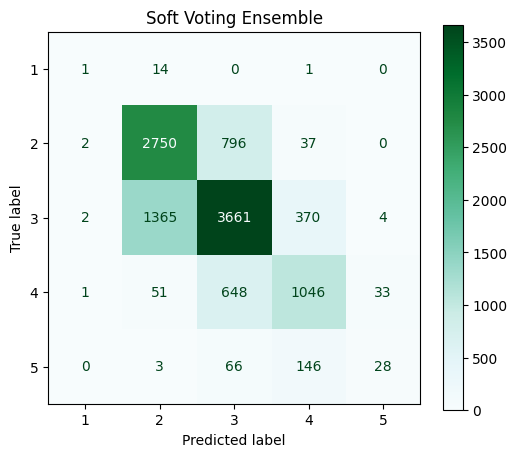

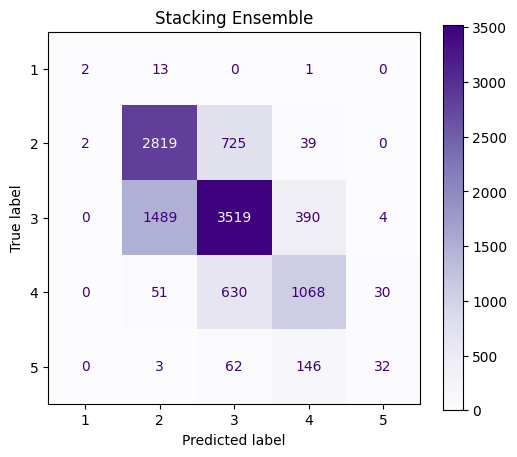

In [40]:
# Confusion matrices for both ensembles
for pred, title, cmap, fname in [
    (pred_voting, "Soft Voting Ensemble",  "BuGn", "confusion_matrix_voting.png"),
    (pred_stack,  "Stacking Ensemble",     "Purples", "confusion_matrix_stacking.png"),
]:
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, cmap=cmap)
    ax.set_title(title)
    fig.savefig(f"/content/drive/MyDrive/{fname}", dpi=150, bbox_inches="tight")
    plt.show()

In [41]:
#comparing the ensembles against baseline models
ensemble_results = {}
for name, pred in [
    ("HGB weighted (best single)", pred_final),
    ("LogReg + FE",                pred_logreg_fe),
    ("MLP",                        pred_mlp),
    ("Voting ensemble",            pred_voting),
    ("Stacking ensemble",          pred_stack),
]:
    yt = np.asarray(y_test); pr = np.asarray(pred)
    under = {lvl: round(100 * (pr[yt == lvl] > lvl).mean(), 1) for lvl in [2, 3, 4]}
    r2, r3, r4 = recall_score(y_test, pred, labels=[2, 3, 4], average=None, zero_division=0)
    ensemble_results[name] = {
        "Accuracy":    round((pred == y_test).mean(), 3),
        "F1 Macro":    round(f1_score(y_test, pred, average="macro"), 3),
        "F1 Weighted": round(f1_score(y_test, pred, average="weighted"), 3),
        "ESI2 Recall": round(r2, 3),
        "ESI3 Recall": round(r3, 3),
        "ESI4 Recall": round(r4, 3),
        "UT2%": under[2],
        "UT 3%": under[3],
        "UT 4%": under[4],
    }

comparison_ensemble = pd.DataFrame(ensemble_results).T
print(comparison_ensemble)

                            Accuracy  F1 Macro  F1 Weighted  ESI2 Recall  ESI3 Recall  ESI4 Recall  UT2%  UT 3%  UT 4%
HGB weighted (best single)     0.636     0.415        0.629        0.797        0.620        0.430  19.6    4.9    2.9
LogReg + FE                    0.690     0.520        0.684        0.625        0.779        0.630  37.4    8.3    1.5
MLP                            0.688     0.505        0.682        0.604        0.797        0.609  39.5    8.2    1.8
Voting ensemble                0.679     0.458        0.674        0.767        0.678        0.588  23.2    6.9    1.9
Stacking ensemble              0.675     0.484        0.669        0.786        0.651        0.600  21.3    7.3    1.7


###Exploring The Dataset 🔎



> Looking at ESI 2 and 4 cases that were undertriaged. This is important because esi 2 patients are serious cases that cant wait as long as esi 3 cases. Additionally ESI 4 cases are semi-urgent cases and shouldnt be classified as non-emergent cases



In [42]:
#using the stacking ensemble
analysis_pred = pred_stack
MODEL_NAME = "Stacking ensemble"

Xte  = X_test_fe.reset_index(drop=True).copy()   # features
yte  = np.asarray(y_test)                         # true ESI
pred = np.asarray(analysis_pred)                  # predicted ESI

# Feature groups grouped in various columns that we'll disect
VITAL_COLS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
              "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
RATIO_COLS = ["shock_index", "pulse_pressure", "spo2_rr_ratio"]
FLAG_COLS  = ["is_tachypneic", "is_hypoxic", "is_febrile", "is_hypothermic",
              "is_bradycardic", "is_tachycardic", "is_hyperglycaemic",
              "resp_distress", "red_flag_count"]
DEMO_COLS  = ["age", "gender_Male"] + [c for c in Xte.columns if c.startswith("arrivalmode_")]

print(f"Analysing under-triage for: {MODEL_NAME}")
print(f"Test patients: {len(yte):,}")

Analysing under-triage for: Stacking ensemble
Test patients: 11,025


In [43]:
def undertriage_profile(level, cols, ref_level, sort_by_effect=True):
    """
    Compare three groups of patients:
      - under triaged patients
      - true patients with the correct/true ESI levels
      - reference/predictive group (the level they get mistaken for)

    Cohen's d puts every feature on the SAME scale so you can rank which ones actually
    separate the under triaged from the correctly triaged. """

    is_level = yte == level
    under    = is_level & (pred > level)
    correct  = is_level & (pred == level)
    n_all, n_under, n_correct = is_level.sum(), under.sum(), correct.sum()

    print(f"\nTRUE ESI {level}   (model: {MODEL_NAME})")
    print(f"Under Triaged: {n_under}/{n_all} ({100*n_under/n_all:.1f}%)   Correct ESI Level: {n_correct}")
    sent = pd.Series(pred[under]).value_counts().sort_index()
    print("sent instead to ESI:", {int(k): int(v) for k, v in sent.items()})

    u = Xte.loc[under,   cols]
    c = Xte.loc[correct, cols]
    r = Xte.loc[yte == ref_level, cols]

    # pooled standard deviation of the two groups being compared (under triaged vs true)
    nu, nc = len(u), len(c)
    pooled_sd = np.sqrt(((nu - 1) * u.var(ddof=1) + (nc - 1) * c.var(ddof=1)) / (nu + nc - 2))
    cohens_d = (u.mean() - c.mean()) / pooled_sd.replace(0, np.nan)

    tbl = pd.DataFrame({
        "under triaged mean":                u.mean(),
        "true esi mean":              c.mean(),
        f"ESI{ref_level} mean":  r.mean(),
        "under triage med":                 u.median(),
        "true esi  med":               c.median(),
        "mean diff":                 u.mean() - c.mean(),
        "cohens_d":                  cohens_d,
    }).round(2)

    if sort_by_effect:
        tbl = tbl.reindex(tbl["cohens_d"].abs().sort_values(ascending=False).index)
    return tbl

In [44]:
# --- ESI 2: vitals, ratios, and red-flag rates (under-triaged vs correct vs true-ESI-3) ---

prof2 = undertriage_profile(2, VITAL_COLS + RATIO_COLS + FLAG_COLS, ref_level=3)
print(prof2.to_string())


TRUE ESI 2   (model: Stacking ensemble)
Under Triaged: 764/3585 (21.3%)   Correct ESI Level: 2819
sent instead to ESI: {3: 725, 4: 39}
                   under triaged mean  true esi mean  ESI3 mean  under triage med  true esi  med  mean diff  cohens_d
red_flag_count                   0.38           0.68       0.41              0.00           1.00      -0.30     -0.40
triage_vital_o2                 97.30          96.30      97.16             98.00          97.00       1.00      0.39
resp_distress                    0.02           0.12       0.04              0.00           0.00      -0.10     -0.33
is_hypoxic                       0.00           0.05       0.01              0.00           0.00      -0.05     -0.27
shock_index                      0.65           0.70       0.65              0.64           0.67      -0.06     -0.27
is_tachypneic                    0.02           0.08       0.03              0.00           0.00      -0.06     -0.24
triage_vital_hr                 85.38 

In [45]:
# --- ESI 4: vitals, ratios, and red-flag rates (under-triaged vs correct vs true-ESI-5) ---

prof4 = undertriage_profile(4, VITAL_COLS + RATIO_COLS + FLAG_COLS, ref_level=5)
print(prof4.to_string())


TRUE ESI 4   (model: Stacking ensemble)
Under Triaged: 30/1779 (1.7%)   Correct ESI Level: 1068
sent instead to ESI: {5: 30}
                   under triaged mean  true esi mean  ESI5 mean  under triage med  true esi  med  mean diff  cohens_d
triage_vital_hr                 77.22          84.16      82.58             78.00          84.00      -6.95     -0.54
is_bradycardic                   0.07           0.02       0.03              0.00           0.00       0.05      0.33
triage_vital_rr                 17.03          17.45      17.24             18.00          18.00      -0.42     -0.29
spo2_rr_ratio                    5.77           5.64       5.71              5.50           5.50       0.13      0.25
shock_index                      0.61           0.65       0.64              0.59           0.64      -0.03     -0.25
triage_vital_temp               97.91          98.05      97.91             98.00          98.10      -0.14     -0.23
triage_vital_dbp                78.47          8

In [46]:
def cc_enrichment(level, min_count=5, top=12):
    """Chief complaints MOST over represented among the under-triaged vs correctly triaged."""
    is_level = yte == level
    under    = is_level & (pred > level)
    correct  = is_level & (pred == level)
    cc = [c for c in Xte.columns if c.startswith("cc_")]
    tbl = pd.DataFrame({
        "under triaged count":    Xte.loc[under, cc].sum().astype(int),
        "under triage %":    100 * Xte.loc[under, cc].mean(),
        "correctly triaged %":  100 * Xte.loc[correct, cc].mean(),
    })
    tbl["gap"] = tbl["under triage %"] - tbl["correctly triaged %"]
    tbl = tbl[tbl["under triaged count"] >= min_count]                 # ignore rare complaints
    return tbl.sort_values("gap", ascending=False).head(top).round(1)

print("ESI 2 — chief complaints over-represented among UNDER-TRIAGED patients:")
print(cc_enrichment(2))
print("\nESI 4 — chief complaints over-represented among UNDER-TRIAGED patients:")
print(cc_enrichment(4, min_count=3))

ESI 2 — chief complaints over-represented among UNDER-TRIAGED patients:
                                   under triaged count  under triage %  correctly triaged %   gap
cc_abdominalpain                                   167            21.9                  2.3  19.6
cc_other                                            97            12.7                  5.1   7.6
cc_headache-newonsetornewsymptoms                   38             5.0                  0.7   4.2
cc_legswelling                                      28             3.7                  0.2   3.5
cc_emesis                                           36             4.7                  1.2   3.5
cc_backpain                                         26             3.4                  0.4   3.0
cc_elevatedbloodsugar-nosymptoms                    21             2.7                  0.3   2.4
cc_nausea                                           21             2.7                  0.4   2.4
cc_flankpain                                  

In [47]:
# --- ESI 2: how did the under-triaged arrive, and who were they? ---
# Under-triage often tracks with lower acuity arrival vs ambulance/wheelchair.
prof2_demo = undertriage_profile(2, DEMO_COLS, ref_level=3)
print(prof2_demo.to_string())


TRUE ESI 2   (model: Stacking ensemble)
Under Triaged: 764/3585 (21.3%)   Correct ESI Level: 2819
sent instead to ESI: {3: 725, 4: 39}
                                   under triaged mean  true esi mean  ESI3 mean  under triage med  true esi  med  mean diff  cohens_d
arrivalmode_ambulance                            0.25           0.59       0.29               0.0            1.0      -0.34     -0.72
age                                             54.75          62.54      55.21              54.0           62.0      -7.79     -0.42
arrivalmode_Walk-in                              0.21           0.12       0.23               0.0            0.0       0.09      0.27
gender_Male                                      0.40           0.50       0.38               0.0            0.0      -0.10     -0.20
arrivalmode_Public Transportation                0.01           0.00       0.01               0.0            0.0       0.01      0.09
arrivalmode_Other                                0.01       

In [48]:
# --- ESI 4: how did the under-triaged arrive, and who were they? ---

prof4_demo = undertriage_profile(4, DEMO_COLS, ref_level=5)
print(prof4_demo.to_string())


TRUE ESI 4   (model: Stacking ensemble)
Under Triaged: 30/1779 (1.7%)   Correct ESI Level: 1068
sent instead to ESI: {5: 30}
                                   under triaged mean  true esi mean  ESI5 mean  under triage med  true esi  med  mean diff  cohens_d
arrivalmode_Walk-in                              0.60           0.43       0.39               1.0            0.0       0.17      0.34
arrivalmode_Public Transportation                0.03           0.01       0.01               0.0            0.0       0.02      0.19
age                                             40.87          42.93      46.61              40.0           43.0      -2.06     -0.13
gender_Male                                      0.47           0.40       0.50               0.0            0.0       0.06      0.13
arrivalmode_ambulance                            0.03           0.04       0.09               0.0            0.0      -0.01     -0.06
arrivalmode_Other                                0.00           0.00  

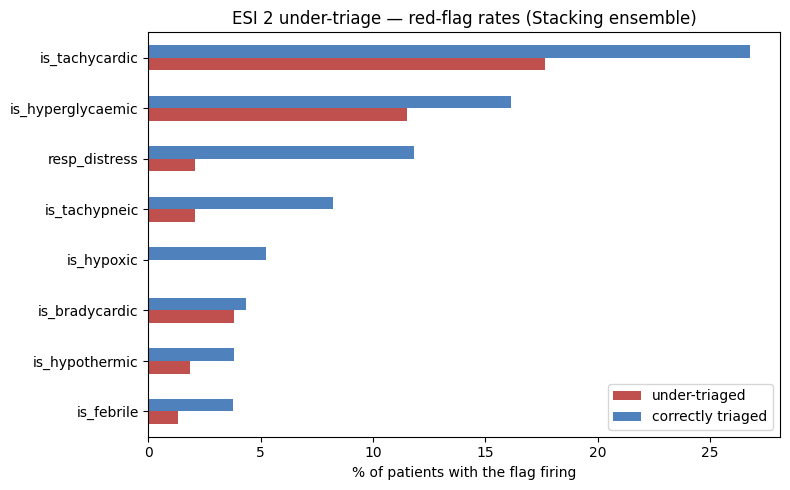

In [49]:
# --- ESI 2 under triaged vs correctly triaged ---
flags = ["is_tachypneic", "is_hypoxic", "is_febrile", "is_hypothermic",
         "is_bradycardic", "is_tachycardic", "is_hyperglycaemic", "resp_distress"]
is2 = yte == 2; u = is2 & (pred > 2); c = is2 & (pred == 2)
rate = pd.DataFrame({
    "under-triaged": 100 * Xte.loc[u, flags].mean(),
    "correctly triaged": 100 * Xte.loc[c, flags].mean(),
}).sort_values("correctly triaged")

ax = rate.plot(kind="barh", figsize=(8, 5), color=["#c0504d", "#4f81bd"])
ax.set_xlabel("% of patients with the flag firing")
ax.set_title(f"ESI 2 under-triage — red-flag rates ({MODEL_NAME})")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/esi2_undertriage_flags.png", dpi=150, bbox_inches="tight")
plt.show()

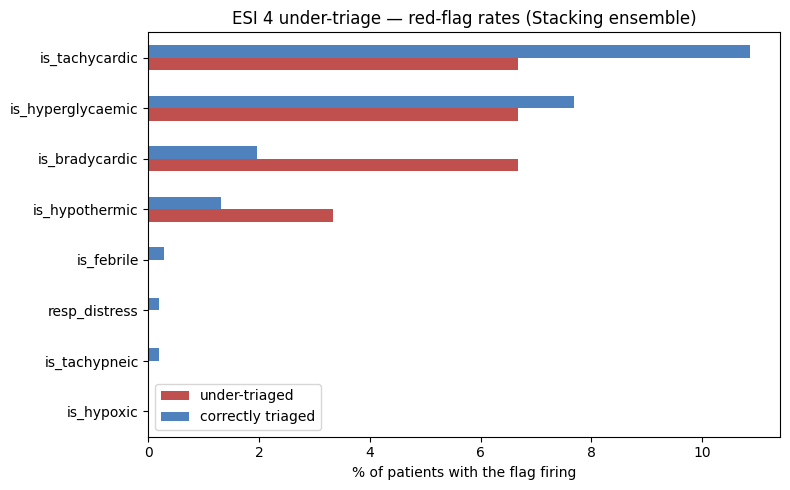

In [50]:
# --- ESI 4 under triaged vs correctly triaged ---
flags = ["is_tachypneic", "is_hypoxic", "is_febrile", "is_hypothermic",
         "is_bradycardic", "is_tachycardic", "is_hyperglycaemic", "resp_distress"]
is4 = yte == 4; u = is4 & (pred > 4); c = is4 & (pred == 4)
rate = pd.DataFrame({
    "under-triaged": 100 * Xte.loc[u, flags].mean(),
    "correctly triaged": 100 * Xte.loc[c, flags].mean(),
}).sort_values("correctly triaged")

ax = rate.plot(kind="barh", figsize=(8, 5), color=["#c0504d", "#4f81bd"])
ax.set_xlabel("% of patients with the flag firing")
ax.set_title(f"ESI 4 under-triage — red-flag rates ({MODEL_NAME})")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/esi2_undertriage_flags.png", dpi=150, bbox_inches="tight")
plt.show()